<a href="https://colab.research.google.com/github/ramyanagavelli463-maker/MyPortfolio/blob/main/Sales_Prediction_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('/content/advertising.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 4


In [6]:
print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


In [7]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [10]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Dataset shape: (200, 4)


In [13]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [14]:
print(df.dtypes)

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


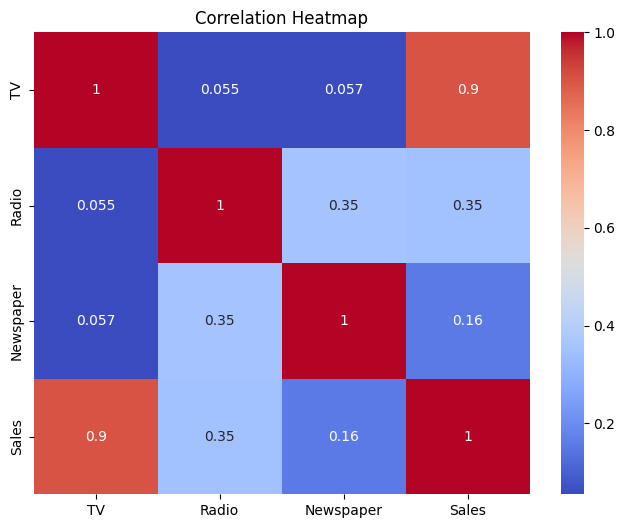

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

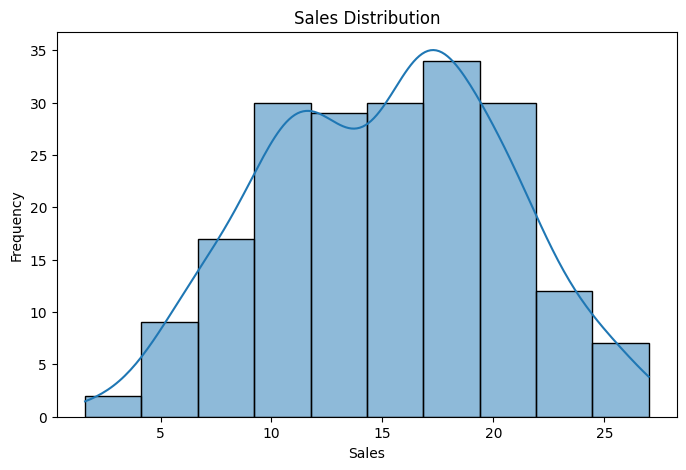

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    kde=True
)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

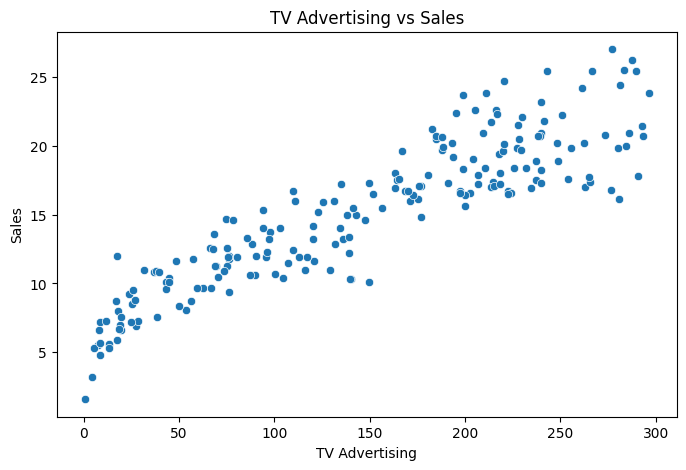

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')

plt.show()

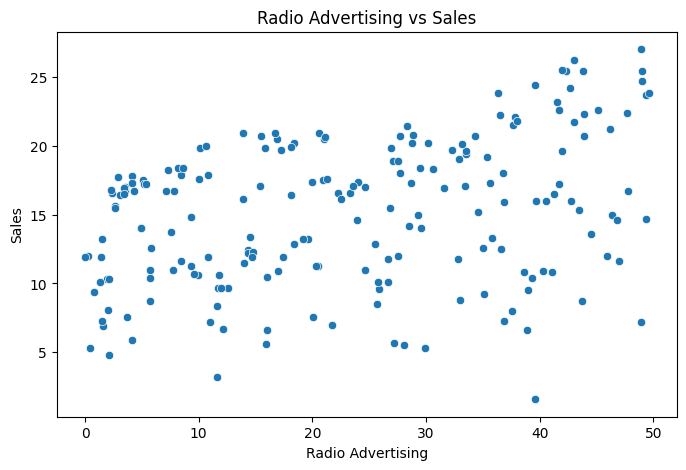

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')

plt.show()

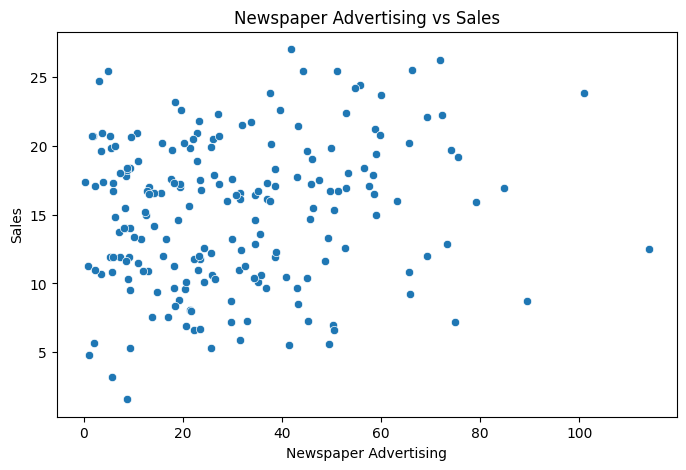

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Newspaper',
    y='Sales'
)

plt.title('Newspaper Advertising vs Sales')
plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')

plt.show()

In [20]:
X = df[
    [
        'TV',
        'Radio',
        'Newspaper'
    ]
]

y = df['Sales']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 160
Testing rows: 40


In [22]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
linear_predictions = linear_model.predict(X_test)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [24]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 1.2748262109549338
RMSE: 1.7052146229349223
R²  : 0.9059011844150826


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
rf_predictions = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_predictions[:10])

First 10 predictions:
[17.4155 22.425  19.8375  6.7945 22.962  13.602  22.6805  9.5935 16.88
 16.84  ]


In [27]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 0.9140749999999972
RMSE: 1.1828469205691836
R²  : 0.9547224261434059


In [28]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse
    ],
    'R2 Score': [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest,0.914075,1.182847,0.954722


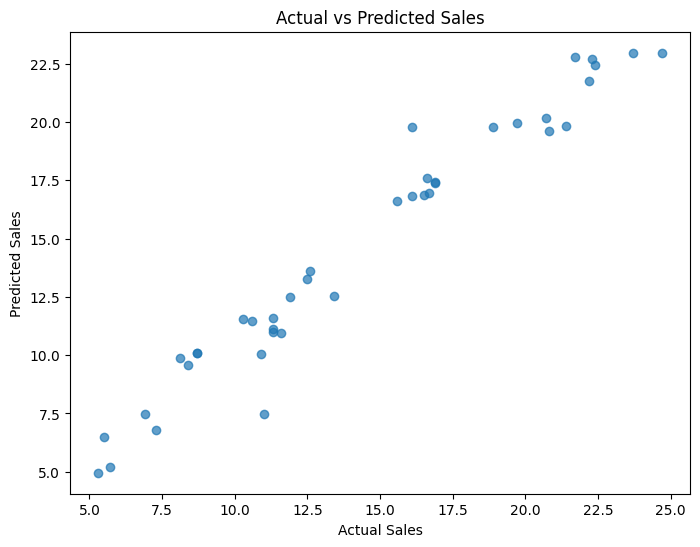

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title('Actual vs Predicted Sales')

plt.show()

In [30]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_predictions
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.4155
1,22.4,22.4250
2,21.4,19.8375
3,7.3,6.7945
4,24.7,22.9620
5,12.6,13.6020
6,22.3,22.6805
7,8.4,9.5935
8,16.5,16.8800
9,16.1,16.8400


In [31]:
new_advertising = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [20]
})

predicted_sales = rf_model.predict(
    new_advertising
)

print(
    "Predicted Sales:",
    round(predicted_sales[0], 2)
)

Predicted Sales: 14.85


In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,TV,0.844376
1,Radio,0.136431
2,Newspaper,0.019194


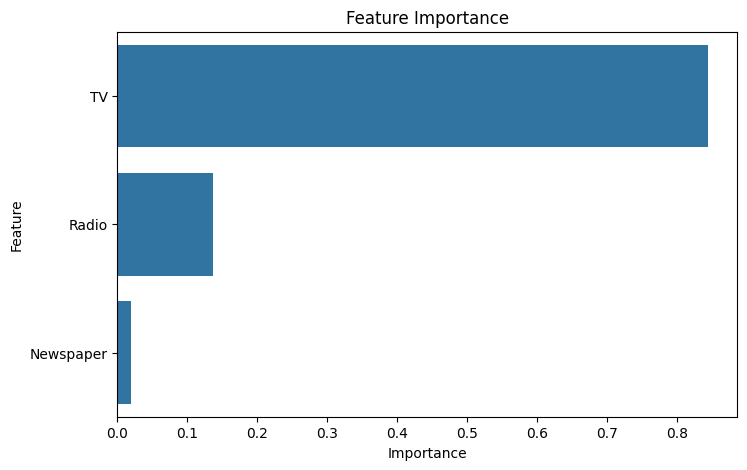

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

In [34]:
final_results = pd.DataFrame({
    'Metric': [
        'Mean Absolute Error (MAE)',
        'Root Mean Squared Error (RMSE)',
        'R² Score'
    ],
    'Linear Regression': [
        linear_mae,
        linear_rmse,
        linear_r2
    ],
    'Random Forest': [
        rf_mae,
        rf_rmse,
        rf_r2
    ]
})

final_results

,Metric,Linear Regression,Random Forest
0,Mean Absolute Error (MAE),1.274826,0.914075
1,Root Mean Squared Error (RMSE),1.705215,1.182847
2,R² Score,0.905901,0.954722


# 📊 Sales Prediction Using Python

## Objective

The objective of this project is to analyze the relationship between advertising expenditure and sales and develop machine learning models to predict sales.

## Methodology

1. Load the sales and advertising dataset.
2. Explore the dataset and understand its structure.
3. Check missing values and duplicate records.
4. Perform exploratory data analysis.
5. Visualize the relationship between advertising channels and sales.
6. Perform correlation analysis.
7. Separate input features and target variable.
8. Split the dataset into training and testing sets.
9. Train a Linear Regression model.
10. Train a Random Forest Regression model.
11. Evaluate both models using MAE, RMSE and R² score.
12. Compare model performance.
13. Analyze feature importance.
14. Predict sales for a new advertising budget.

## Conclusion

In this project, machine learning techniques were used to predict sales based on advertising expenditure.

The dataset was explored and cleaned before performing exploratory data analysis. Visualizations and correlation analysis were used to understand the relationship between advertising channels and sales.

Linear Regression and Random Forest Regression models were trained and evaluated using MAE, RMSE and R² score. The models were compared based on their prediction performance.

Feature importance was also analyzed to understand the contribution of the different advertising channels. Finally, the trained model was used to predict sales for a new advertising budget.